**FINAL PROJECT**

In [ ]:
## import libraries
from __future__ import print_function
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable

**Import the Dataset**

In [ ]:
## import dataset
import pandas
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file
file_path = "credit_card_fraud_2026.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uditjain13/credit-card-fraud-detection-2026",
  file_path)

for col in df.columns:
  try:
    print(str(col), df[col].mean())
    print()
  except TypeError:
    print(str(col), str(df[col].mode()))
    print()


/tmp/ipykernel_1389/2548214591.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 2.63M/2.63M [00:00<00:00, 5.40MB/s]


transaction_id 10000.5

amount_usd 132.424597

merchant_category 0    Online Retail
Name: merchant_category, dtype: object

card_type 0    Visa
Name: card_type, dtype: object

auth_method 0    3D Secure
Name: auth_method, dtype: object

channel 0    Online
Name: channel, dtype: object

device_type 0    Android Phone
Name: device_type, dtype: object

is_foreign_transaction 0.062

hours_since_last_txn 8.950827499999999

txn_count_last_24h 3.19165

distance_from_home_km 22.1395245

card_age_months 46.93755

customer_age 49.6694

account_balance_usd 3316.662598

is_new_merchant 0.23005

used_vpn 0.08795

ip_country_mismatch 0.0583

billing_shipping_mismatch 0.04365

cvv_retry_count 0.1813

velocity_score 19.807734999999997

time_of_day_hour 11.53365

day_of_week 2.99875

is_ai_generated_scam_attempt 0.01875

merchant_risk_score 37.40039

prior_disputes 0.28125

is_fraud 0.01695



**Data Pre-Processing**

In [ ]:
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Dropping transaction_id
df = df.drop(columns=["transaction_id"]).drop_duplicates()

# Convert t/f columns to 1/0 so the model can use them
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

#one hot encoding the categorical columns
cat_cols = ["merchant_category", "card_type", "auth_method", "channel", "device_type"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)

#split into features and label
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

#making train/test split before scaling
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=33, stratify=y_temp)

#scale numeric columns and fitting on training data only
num_cols = ["amount_usd", "hours_since_last_txn", "txn_count_last_24h", "distance_from_home_km",
            "card_age_months", "customer_age", "account_balance_usd", "cvv_retry_count",
            "velocity_score", "time_of_day_hour", "day_of_week", "merchant_risk_score", "prior_disputes"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
# list column names
print(list(X_train))
print(list(X_val))
print(list(X_test))

['amount_usd', 'is_foreign_transaction', 'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km', 'card_age_months', 'customer_age', 'account_balance_usd', 'is_new_merchant', 'used_vpn', 'ip_country_mismatch', 'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score', 'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt', 'merchant_risk_score', 'prior_disputes', 'merchant_category_Crypto Exchange', 'merchant_category_Electronics', 'merchant_category_Fuel', 'merchant_category_Gaming', 'merchant_category_Gift Cards', 'merchant_category_Groceries', 'merchant_category_Healthcare', 'merchant_category_Online Retail', 'merchant_category_Restaurants', 'merchant_category_Streaming', 'merchant_category_Travel', 'merchant_category_Utilities', 'card_type_Amex', 'card_type_Discover', 'card_type_Mastercard', 'card_type_RuPay', 'card_type_Visa', 'auth_method_3D Secure', 'auth_method_Biometric', 'auth_method_No Authentication', 'auth_method_OTP', 'auth_method_PIN', 'ch

In [ ]:
# export scaler
import joblib

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

**LOGISTIC REGRESSION MODEL**

In [ ]:
# Train Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss

log_reg_model = LogisticRegression()
log_reg_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Make predictions with validation set
y_pred_val = log_reg_model.predict(X_val)
y_prob_val = log_reg_model.predict_proba(X_val)[:, 1]

In [ ]:
# Evaluate accuracy
accuracy = accuracy_score(y_val, y_pred_val)
average_loss = log_loss(y_val, y_prob_val)

print("Accuracy:", accuracy)
print("Average loss:", average_loss)


Accuracy: 0.9853125
Average loss: 0.0498588662298038


In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report, Validation:")
print(classification_report(y_val, y_pred_val, zero_division=0))

Logistic Regression Classification Report, Validation:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3146
           1       0.71      0.22      0.34        54

    accuracy                           0.99      3200
   macro avg       0.85      0.61      0.67      3200
weighted avg       0.98      0.99      0.98      3200



In [ ]:
# Test with different thresholds
for threshold in [0.5, 0.4, 0.3, 0.25, 0.2,0.1]:
  y_pred_val = (y_prob_val >= threshold).astype(int)
  print(f"\nThreshold: {threshold}")
  print(classification_report(y_val, y_pred_val))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3146
           1       0.71      0.22      0.34        54

    accuracy                           0.99      3200
   macro avg       0.85      0.61      0.67      3200
weighted avg       0.98      0.99      0.98      3200


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3146
           1       0.50      0.30      0.37        54

    accuracy                           0.98      3200
   macro avg       0.74      0.65      0.68      3200
weighted avg       0.98      0.98      0.98      3200


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3146
           1       0.49      0.41      0.44        54

    accuracy                           0.98      3200
   macro avg       0.74      0.70      0.72      3200
weighted avg       0.98   

In [ ]:
# Make predictions with test set
# Choose 0.2 as threshold
y_prob = log_reg_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.2).astype(int)

In [ ]:
# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
average_loss = log_loss(y_test, y_prob)

print("Accuracy:", accuracy)
print("Average loss:", average_loss)

Accuracy: 0.981
Average loss: 0.047069697901286546


In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3932
           1       0.45      0.51      0.48        68

    accuracy                           0.98      4000
   macro avg       0.72      0.75      0.73      4000
weighted avg       0.98      0.98      0.98      4000



In [ ]:
#PR AUC Sincre our set is highly imbalanced
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

PR-AUC: 0.4667395089427493


In [ ]:
# export LR model
import joblib

joblib.dump(log_reg_model, 'log_reg_model.pkl')

['log_reg_model.pkl']

### Feature Importance from Scikit-learn Logistic Regression

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

coefficients = log_reg_model.coef_[0]

feature_names = X.columns.tolist()

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient_Magnitude': np.abs(coefficients),
    'Coefficient_Value': coefficients
})

feature_importance_df = feature_importance_df.sort_values(by='Coefficient_Magnitude', ascending=False)

# Select the top 3 most important features
top_3_features = feature_importance_df.head(3)

print("Top 3 Feature from Logistic Regression:")
display(top_3_features)
print()
print()
print("Feature Importance from Most to Least:")
display(feature_importance_df)


Top 3 Feature from Logistic Regression:


,Feature,Coefficient_Magnitude,Coefficient_Value
16,is_ai_generated_scam_attempt,2.544042,2.544042
10,ip_country_mismatch,2.534855,2.534855
11,billing_shipping_mismatch,2.474672,2.474672




Feature Importance from Most to Least:


,Feature,Coefficient_Magnitude,Coefficient_Value
16,is_ai_generated_scam_attempt,2.544042,2.544042
10,ip_country_mismatch,2.534855,2.534855
11,billing_shipping_mismatch,2.474672,2.474672
9,used_vpn,1.647624,1.647624
38,auth_method_No Authentication,1.631821,1.631821
8,is_new_merchant,1.334275,1.334275
1,is_foreign_transaction,1.042022,1.042022
17,merchant_risk_score,1.023913,1.023913
37,auth_method_Biometric,1.004069,-1.004069
12,cvv_retry_count,0.845565,0.845565


Does strong authentication (biometric, 3D Secure) actually suppress fraud?

/tmp/ipykernel_1389/2836844346.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient_Value', y='Feature', data=auth_features_df, palette='coolwarm')


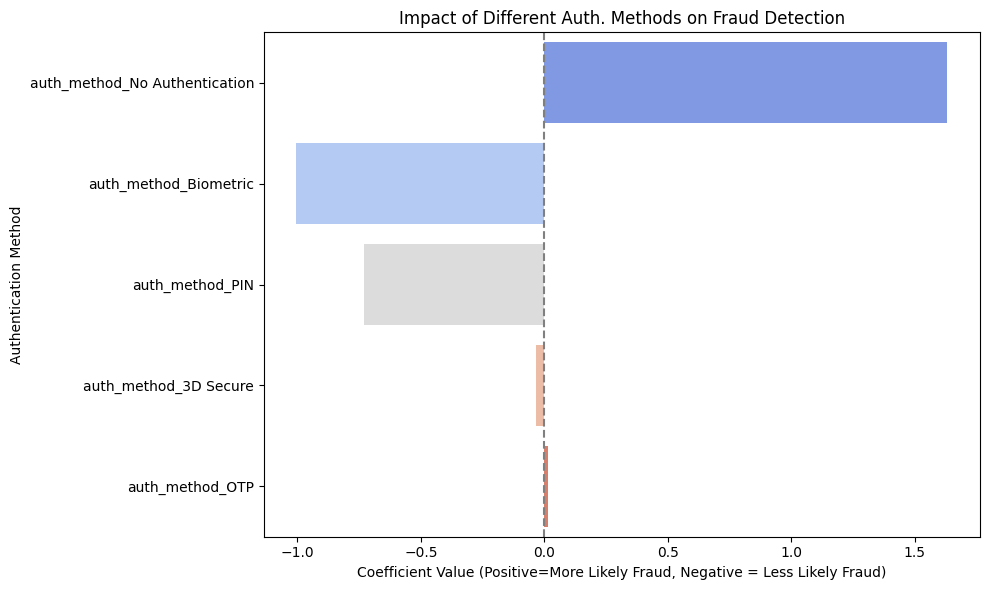

In [ ]:
auth_features_df = feature_importance_df[feature_importance_df['Feature'].str.startswith('auth_method_')]

# horizontal bar plot
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient_Value', y='Feature', data=auth_features_df, palette='coolwarm')
plt.title('Impact of Different Auth. Methods on Fraud Detection')
plt.xlabel('Coefficient Value (Positive=More Likely Fraud, Negative = Less Likely Fraud)')
plt.ylabel('Authentication Method')
plt.axvline(x=0, color='grey', linestyle='--')
plt.tight_layout()
plt.show()


### Fully Connected Neural Network




In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

class FraudNN(nn.Module):
    def __init__(self, input_dim):
        super(FraudNN, self).__init__()

        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)


        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.fc2(out)
        out = self.relu2(out)
        out = self.dropout2(out)

        out = self.fc3(out)
        out = self.sigmoid(out)
        return out

input_dim = X_train.shape[1]
model = FraudNN(input_dim)
print(model)

FraudNN(
  (fc1): Linear(in_features=54, out_features=64, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [ ]:
loss_func = nn.BCELoss(reduction='none')
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 35
model.train()

weight_fraud= float((y_train == 0).sum() /((y_train == 1).sum()))


for epoch in range(epochs):
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)

        weights = torch.where(batch_y == 1, weight_fraud,1.0)
        loss = (loss_func(outputs, batch_y) * weights).mean()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs}: Loss: {epoch_loss:.4f}")

Epoch 1/35: Loss: 1.3679
Epoch 2/35: Loss: 1.3504
Epoch 3/35: Loss: 1.3298
Epoch 4/35: Loss: 1.2970
Epoch 5/35: Loss: 1.2432
Epoch 6/35: Loss: 1.1680
Epoch 7/35: Loss: 1.0741
Epoch 8/35: Loss: 0.9814
Epoch 9/35: Loss: 0.8927
Epoch 10/35: Loss: 0.8455
Epoch 11/35: Loss: 0.8009
Epoch 12/35: Loss: 0.7659
Epoch 13/35: Loss: 0.7390
Epoch 14/35: Loss: 0.7186
Epoch 15/35: Loss: 0.6827
Epoch 16/35: Loss: 0.6933
Epoch 17/35: Loss: 0.6703
Epoch 18/35: Loss: 0.6395
Epoch 19/35: Loss: 0.6208
Epoch 20/35: Loss: 0.6166
Epoch 21/35: Loss: 0.6031
Epoch 22/35: Loss: 0.5916
Epoch 23/35: Loss: 0.5805
Epoch 24/35: Loss: 0.5698
Epoch 25/35: Loss: 0.5717
Epoch 26/35: Loss: 0.5670
Epoch 27/35: Loss: 0.5412
Epoch 28/35: Loss: 0.5564
Epoch 29/35: Loss: 0.5458
Epoch 30/35: Loss: 0.5061
Epoch 31/35: Loss: 0.5236
Epoch 32/35: Loss: 0.5244
Epoch 33/35: Loss: 0.5325
Epoch 34/35: Loss: 0.4814
Epoch 35/35: Loss: 0.4868


In [ ]:
from sklearn.metrics import classification_report

model.eval()
with torch.no_grad():
    y_prob_val_nn = model(X_val_tensor).numpy().ravel()

In [ ]:

for t in [0.3, 0.5, 0.7, 0.8, 0.9,0.96, 0.98]:
    print(f"NN, validation, threshold {t}")
    print(classification_report(y_val, (y_prob_val_nn >= t).astype(int), zero_division=0))

NN, validation, threshold 0.3
              precision    recall  f1-score   support

           0       1.00      0.82      0.90      3146
           1       0.08      0.85      0.14        54

    accuracy                           0.82      3200
   macro avg       0.54      0.84      0.52      3200
weighted avg       0.98      0.82      0.89      3200

NN, validation, threshold 0.5
              precision    recall  f1-score   support

           0       1.00      0.89      0.94      3146
           1       0.11      0.78      0.19        54

    accuracy                           0.89      3200
   macro avg       0.55      0.83      0.56      3200
weighted avg       0.98      0.89      0.93      3200

NN, validation, threshold 0.7
              precision    recall  f1-score   support

           0       0.99      0.94      0.97      3146
           1       0.18      0.70      0.28        54

    accuracy                           0.94      3200
   macro avg       0.59      0.82     

In [ ]:
from sklearn.metrics import average_precision_score

best_threshold = 0.96   # chosen on validation
with torch.no_grad():
  test_probs = model(X_test_tensor).numpy().ravel()

  print("Test PR-AUC:", round(average_precision_score(y_test, test_probs), 3))
  print(classification_report(y_test, (test_probs >= best_threshold).astype(int), zero_division=0))

Test PR-AUC: 0.403
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3932
           1       0.65      0.22      0.33        68

    accuracy                           0.98      4000
   macro avg       0.82      0.61      0.66      4000
weighted avg       0.98      0.98      0.98      4000



In [ ]:
import torch

# Save the model's state_dict (weights)
torch.save(model.state_dict(), 'fraud_nn_model.pth')
print("Model weights saved to 'fraud_nn_model.pth'")

Model weights saved to 'fraud_nn_model.pth'
